In [40]:
import os, glob, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

In [41]:
DATA_DIR = os.path.expanduser("~/pqc/signature-esp32/results")

paths = sorted(glob.glob(os.path.join(DATA_DIR, "*.jsonl")))
paths

['/home/momo/pqc/signature-esp32/results/esp32_energy.jsonl',
 '/home/momo/pqc/signature-esp32/results/keypair_ML_DSA_44.jsonl',
 '/home/momo/pqc/signature-esp32/results/sign_ML_DSA_44.jsonl',
 '/home/momo/pqc/signature-esp32/results/verify_ML_DSA_44.jsonl',
 '/home/momo/pqc/signature-esp32/results/whole_ML_DSA_44.jsonl']

In [42]:
def read_jsonl(path):
    rows = []
    bad = 0
    with open(path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError:
                bad += 1
    if bad:
        print(f"⚠️ {os.path.basename(path)} : {bad} lignes JSON invalides ignorées")
    return rows

### Préparation et normalisation des données

Dans cette étape, les colonnes numériques du jeu de données sont converties dans un format numérique afin de faciliter les analyses statistiques et les calculs ultérieurs.

Ensuite, plusieurs métriques mémoire plus explicites sont calculées afin de mieux caractériser la consommation mémoire des algorithmes sur la plateforme **ESP32** :

- **Heap change after operation** : variation nette de la mémoire heap avant et après l’exécution de l’algorithme.
- **Heap peak usage** : estimation du pic de mémoire heap utilisé pendant l’exécution.
- **Heap peak usage during operation** : pic de mémoire observé pendant la mesure interne de l’opération.
- **Largest free block reduction** : diminution du plus grand bloc de mémoire libre, indiquant une pression mémoire potentielle.

Ces métriques permettent d’analyser plus précisément le comportement mémoire des algorithmes cryptographiques, car la simple différence de heap avant/après (`heap_delta_bytes`) ne reflète pas toujours la mémoire réellement utilisée pendant l’exécution.

In [43]:
all_rows = []
for p in paths:
    all_rows.extend(read_jsonl(p))

df = pd.DataFrame(all_rows)
df.head()

,platform,alg,op,ppk_port,voltage_mv,baseline_s,duration_s,baseline_mean_ua,run_mean_ua_raw,run_mean_ua_corrected,run_mean_ua_corrected_clamped,energy_j,baseline_samples,run_samples,returncode,timestamp,command,marker_start_seen,marker_stop_seen,esp_jsonl_count,esp_jsonl_preview,stdout_tail,energy_valid,energy_status,platform_id,mode,pqc_sig_alg,bench_op,iter_idx,msg_len_bytes,time_us,heap_before,heap_after,heap_delta_bytes,heap_min_free_global_bytes,heap_min_during_bytes,largest_before_bytes,largest_min_during_bytes,useful_heap_bytes,extra_heap_bytes,static_stack_used_bytes,total_mem_bytes,pk_len_bytes,sk_len_bytes,sig_len_bytes,ok
0,esp32-local,FALCON_512,keypair,/dev/ttyACM0,3300.0,1.0,48.762617,-1.443969,-0.402425,1.041543,1.041543,0.000168,22880.0,62448.0,-15.0,2026-03-13T15:50:07,"bash -lc ""source ~/Téléchargements/esp-idf/exp...",True,True,20.0,"[{""platform_id"":""esp32-local"",""mode"":""local"",""...","""mode"":""local"",""pqc_sig_alg"":""FALCON_512"",""ben...",False,preliminary,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,esp32-local,FALCON_512,sign,/dev/ttyACM0,3300.0,1.0,13.043910,-1.441072,-0.401995,1.039077,1.039077,0.000045,22912.0,62329.0,-15.0,2026-03-13T15:52:36,"bash -lc ""source ~/Téléchargements/esp-idf/exp...",True,True,20.0,"[{""platform_id"":""esp32-local"",""mode"":""local"",""...","1\n{""platform_id"":""esp32-local"",""mode"":""local""...",False,preliminary,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,esp32-local,FALCON_512,verify,/dev/ttyACM0,3300.0,1.0,1.257308,-1.455498,-0.398146,1.057353,1.057353,0.000004,23296.0,61023.0,-15.0,2026-03-13T15:53:32,"bash -lc ""source ~/Téléchargements/esp-idf/exp...",True,True,20.0,"[{""platform_id"":""esp32-local"",""mode"":""local"",""...","32-local"",""mode"":""local"",""pqc_sig_alg"":""FALCON...",False,preliminary,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,esp32-local,FALCON_512,whole,/dev/ttyACM0,3300.0,1.0,46.681973,-1.455490,-0.409285,1.046205,1.046205,0.000161,22528.0,62448.0,-15.0,2026-03-13T15:55:21,"bash -lc ""source ~/Téléchargements/esp-idf/exp...",True,True,20.0,"[{""platform_id"":""esp32-local"",""mode"":""local"",""...","g_alg"":""FALCON_512"",""bench_op"":""whole"",""iter_i...",False,preliminary,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,esp32-local,FALCON_PADDED_512,keypair,/dev/ttyACM0,3300.0,1.0,44.038547,-1.341694,-0.400726,0.940968,0.940968,0.000137,21952.0,62448.0,-15.0,2026-03-13T16:04:09,"bash -lc ""source ~/Téléchargements/esp-idf/exp...",True,True,20.0,"[{""platform_id"":""esp32-local"",""mode"":""local"",""...","N_PADDED_512"",""bench_op"":""keypair"",""iter_idx"":...",False,preliminary,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
num_cols = [
    "iter_idx", "msg_len_bytes", "time_us",
    "heap_before", "heap_after", "heap_delta_bytes",
    "heap_min_free_global_bytes", "heap_min_during_bytes",
    "largest_before_bytes", "largest_min_during_bytes",
    "useful_heap_bytes", "extra_heap_bytes",
    "static_stack_used_bytes", "total_mem_bytes",
    "pk_len_bytes", "sk_len_bytes", "sig_len_bytes",
    "ok"
]

for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df["bench_op"] = df["bench_op"].str.lower()
df["pqc_sig_alg"] = df["pqc_sig_alg"].astype(str)

df_ok = df[df["ok"] == 1].copy()

df_ok[["platform_id", "pqc_sig_alg", "bench_op", "time_us", "total_mem_bytes"]].head()

,platform_id,pqc_sig_alg,bench_op,time_us,total_mem_bytes
32,esp32-local,ML_DSA_44,keypair,54200.0,39212.0
33,esp32-local,ML_DSA_44,keypair,40527.0,39212.0
34,esp32-local,ML_DSA_44,keypair,40527.0,39212.0
35,esp32-local,ML_DSA_44,keypair,40527.0,39212.0
36,esp32-local,ML_DSA_44,keypair,40527.0,39212.0


In [45]:
summary = (
    df_ok.groupby(["pqc_sig_alg", "bench_op"])
         .agg(
             time_median_us=("time_us", "median"),
             useful_heap_mean=("useful_heap_bytes", "mean"),
             extra_heap_mean=("extra_heap_bytes", "mean"),
             static_mem_mean=("static_stack_used_bytes", "mean"),
             total_mem_mean=("total_mem_bytes", "mean")
         )
         .reset_index()
)

summary.head()

,pqc_sig_alg,bench_op,time_median_us,useful_heap_mean,extra_heap_mean,static_mem_mean,total_mem_mean
0,FALCON_512,keypair,2000951.0,0.0,0.0,18423.733333,18423.733333
1,FALCON_512,sign,582234.5,0.0,0.0,44204.000000,44204.000000
2,FALCON_512,verify,13666.0,0.0,0.0,44188.000000,44188.000000
3,FALCON_512,whole,2501056.0,2192.0,0.0,44180.000000,46372.000000
4,FALCON_PADDED_512,keypair,1905864.5,0.0,0.0,18421.600000,18421.600000


In [46]:
op_order = ["keypair", "sign", "verify", "whole"]

time_table = (
    summary.pivot(index="pqc_sig_alg", columns="bench_op", values="time_median_us")
           .reindex(columns=op_order)
)

time_table

bench_op,keypair,sign,verify,whole
pqc_sig_alg,,,,
FALCON_512,2000951.0,582234.5,13666.0,2501056.0
FALCON_PADDED_512,1905864.5,582810.5,13236.0,2656048.0
ML_DSA_44,40527.0,75181.5,32409.5,120669.0
RSA_2048,5320568.0,596350.5,34356.0,4480796.0
SPHINCS_SHA2_128F,450578.0,6795655.5,371829.0,6670692.0
SPHINCS_SHA2_128S,16500590.0,125243510.0,140926.5,141850695.0
SPHINCS_SHAKE_128F,920466.0,21117375.0,1288610.0,23270569.0
SPHINCS_SHAKE_128S,57720478.0,438411850.0,432404.0,496550497.0


In [47]:
mem_table = (
    summary.pivot(index="pqc_sig_alg", columns="bench_op", values="total_mem_mean")
           .reindex(columns=op_order)
)

mem_table

bench_op,keypair,sign,verify,whole
pqc_sig_alg,,,,
FALCON_512,18423.733333,44204.000000,44188.0,46372.000000
FALCON_PADDED_512,18421.600000,44188.000000,44172.0,46359.200000
ML_DSA_44,39212.000000,52748.000000,52732.0,56612.000000
RSA_2048,4327.600000,4182.933333,4164.0,6964.133333
SPHINCS_SHA2_128F,3772.000000,3676.000000,3852.0,3716.000000
SPHINCS_SHA2_128S,3996.000000,4060.000000,4076.0,4132.000000
SPHINCS_SHAKE_128F,3932.000000,4028.000000,4012.0,4068.000000
SPHINCS_SHAKE_128S,4316.000000,6468.000000,6452.0,6508.000000


In [48]:
def plot_grouped_bars(pivot_df, title, ylabel, logy=False):
    pivot_df = pivot_df.dropna(how="all")
    algos = pivot_df.index.tolist()
    ops = pivot_df.columns.tolist()

    x = np.arange(len(algos))
    width = 0.18

    plt.figure(figsize=(12, 6))
    for i, op in enumerate(ops):
        values = pivot_df[op].values
        plt.bar(x + (i - (len(ops)-1)/2) * width, values, width=width, label=op)

    plt.xticks(x, algos, rotation=45, ha="right")
    plt.xlabel("Algorithme")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(title="Opération")
    if logy:
        plt.yscale("log")
    plt.tight_layout()
    plt.show()

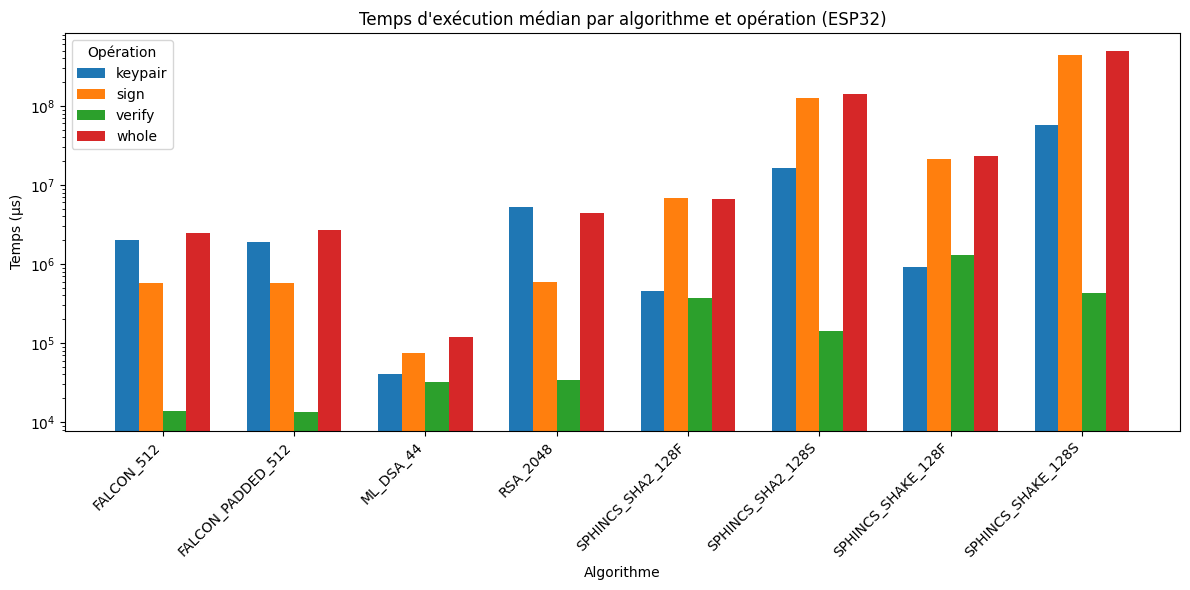

In [49]:
plot_grouped_bars(
    time_table,
    "Temps d'exécution médian par algorithme et opération (ESP32)",
    "Temps (µs)",
    logy=True
)

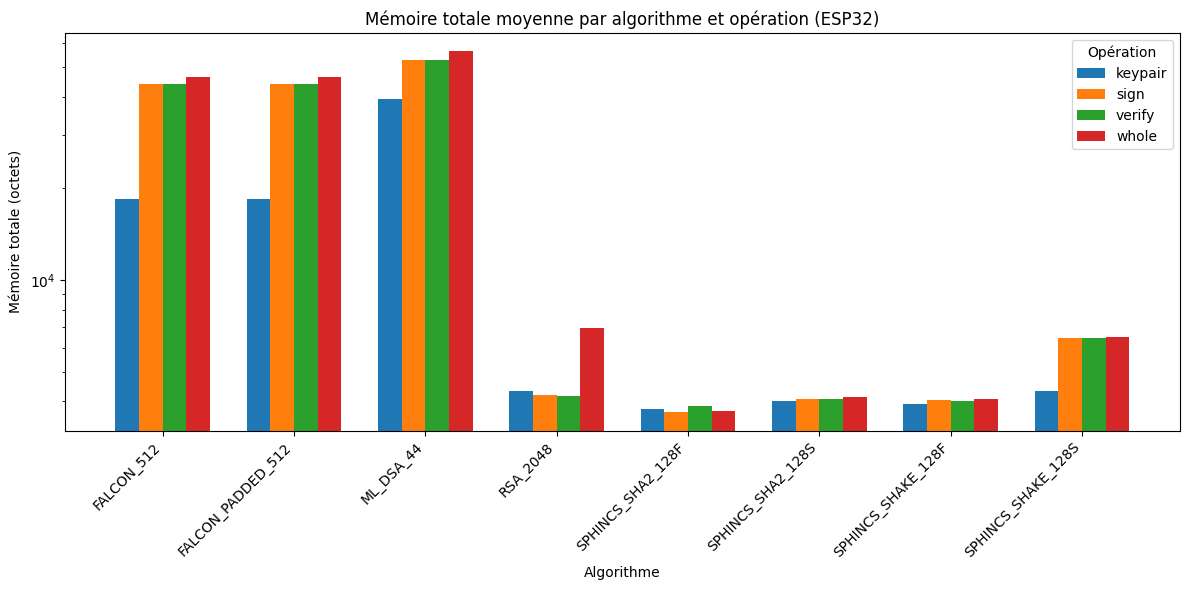

In [50]:
plot_grouped_bars(
    mem_table,
    "Mémoire totale moyenne par algorithme et opération (ESP32)",
    "Mémoire totale (octets)",
    logy=True
)

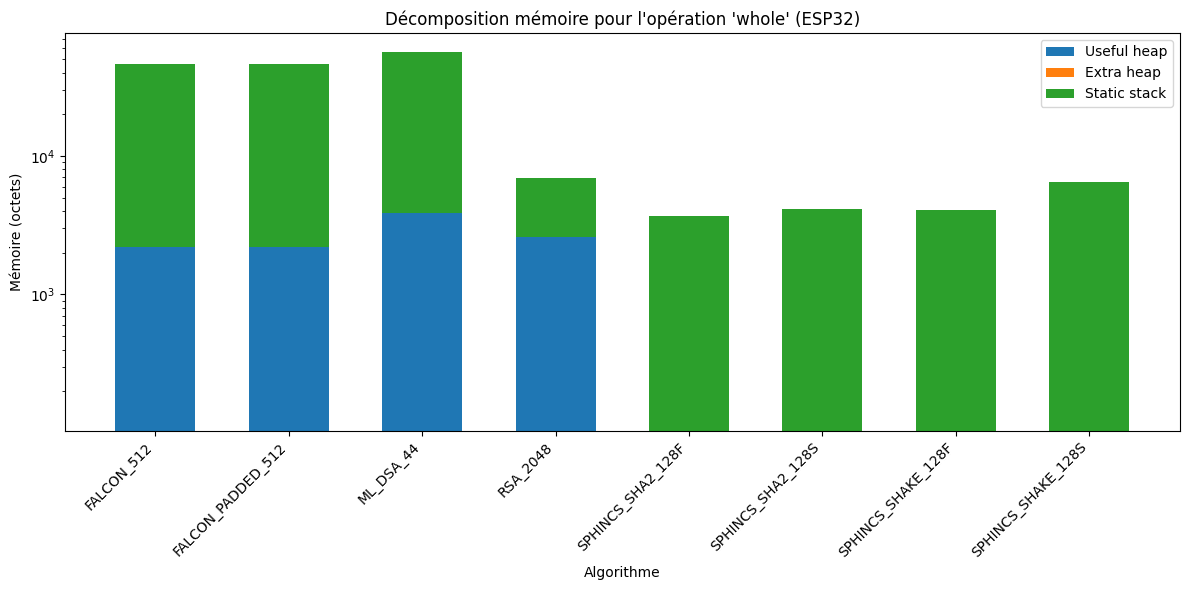

In [51]:
whole_mem = summary[summary["bench_op"] == "whole"].copy().sort_values("pqc_sig_alg")

x = np.arange(len(whole_mem))
width = 0.6

plt.figure(figsize=(12, 6))
plt.bar(x, whole_mem["useful_heap_mean"], width=width, label="Useful heap")
plt.bar(
    x,
    whole_mem["extra_heap_mean"],
    width=width,
    bottom=whole_mem["useful_heap_mean"],
    label="Extra heap"
)
plt.bar(
    x,
    whole_mem["static_mem_mean"],
    width=width,
    bottom=whole_mem["useful_heap_mean"] + whole_mem["extra_heap_mean"],
    label="Static stack"
)

plt.xticks(x, whole_mem["pqc_sig_alg"], rotation=45, ha="right")
plt.xlabel("Algorithme")
plt.ylabel("Mémoire (octets)")
plt.title("Décomposition mémoire pour l'opération 'whole' (ESP32)")
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()

### Analyse des performances et de la mémoire sur ESP32

Cette section résume les résultats expérimentaux obtenus sur la plateforme ESP32 selon deux axes principaux : le temps d’exécution et la mémoire consommée. Les temps sont agrégés par médiane afin de réduire l’impact des valeurs extrêmes, tandis que l’empreinte mémoire est analysée à partir de la mémoire utile, de la mémoire supplémentaire, de la pile statique et de la mémoire totale estimée.

In [65]:
import pandas as pd
import json

rows = []

with open("esp32_energy.jsonl") as f:
    for line in f:
        rows.append(json.loads(line))

df_energy = pd.DataFrame(rows)

df_energy.head()

,platform,alg,op,ppk_port,voltage_mv,baseline_s,duration_s,baseline_mean_ua,run_mean_ua_raw,run_mean_ua_corrected,run_mean_ua_corrected_clamped,energy_j,baseline_samples,run_samples,returncode,timestamp,command,marker_start_seen,marker_stop_seen,esp_jsonl_count,esp_jsonl_preview,stdout_tail,energy_valid,energy_status
0,esp32-local,FALCON_512,keypair,/dev/ttyACM0,3300,1.0,48.762617,-1.443969,-0.402425,1.041543,1.041543,0.000168,22880,62448,-15,2026-03-13T15:50:07,"bash -lc ""source ~/Téléchargements/esp-idf/exp...",True,True,20,"[{""platform_id"":""esp32-local"",""mode"":""local"",""...","""mode"":""local"",""pqc_sig_alg"":""FALCON_512"",""ben...",False,preliminary
1,esp32-local,FALCON_512,sign,/dev/ttyACM0,3300,1.0,13.043910,-1.441072,-0.401995,1.039077,1.039077,0.000045,22912,62329,-15,2026-03-13T15:52:36,"bash -lc ""source ~/Téléchargements/esp-idf/exp...",True,True,20,"[{""platform_id"":""esp32-local"",""mode"":""local"",""...","1\n{""platform_id"":""esp32-local"",""mode"":""local""...",False,preliminary
2,esp32-local,FALCON_512,verify,/dev/ttyACM0,3300,1.0,1.257308,-1.455498,-0.398146,1.057353,1.057353,0.000004,23296,61023,-15,2026-03-13T15:53:32,"bash -lc ""source ~/Téléchargements/esp-idf/exp...",True,True,20,"[{""platform_id"":""esp32-local"",""mode"":""local"",""...","32-local"",""mode"":""local"",""pqc_sig_alg"":""FALCON...",False,preliminary
3,esp32-local,FALCON_512,whole,/dev/ttyACM0,3300,1.0,46.681973,-1.455490,-0.409285,1.046205,1.046205,0.000161,22528,62448,-15,2026-03-13T15:55:21,"bash -lc ""source ~/Téléchargements/esp-idf/exp...",True,True,20,"[{""platform_id"":""esp32-local"",""mode"":""local"",""...","g_alg"":""FALCON_512"",""bench_op"":""whole"",""iter_i...",False,preliminary
4,esp32-local,FALCON_PADDED_512,keypair,/dev/ttyACM0,3300,1.0,44.038547,-1.341694,-0.400726,0.940968,0.940968,0.000137,21952,62448,-15,2026-03-13T16:04:09,"bash -lc ""source ~/Téléchargements/esp-idf/exp...",True,True,20,"[{""platform_id"":""esp32-local"",""mode"":""local"",""...","N_PADDED_512"",""bench_op"":""keypair"",""iter_idx"":...",False,preliminary


In [66]:
df_energy = df_energy.copy()

df_energy["energy_j"] = pd.to_numeric(df_energy["energy_j"], errors="coerce")
df_energy["duration_s"] = pd.to_numeric(df_energy["duration_s"], errors="coerce")
df_energy["run_mean_ua_corrected"] = pd.to_numeric(
    df_energy["run_mean_ua_corrected"], errors="coerce"
)

df_energy = df_energy.dropna(subset=["energy_j"])

In [67]:
df_energy["energy_mj"] = df_energy["energy_j"] * 1000


In [68]:
energy_summary = (
    df_energy
    .groupby(["alg","op"])
    .agg(
        energy_mean=("energy_mj","mean"),
        energy_std=("energy_mj","std"),
        duration_mean=("duration_s","mean")
    )
    .reset_index()
)

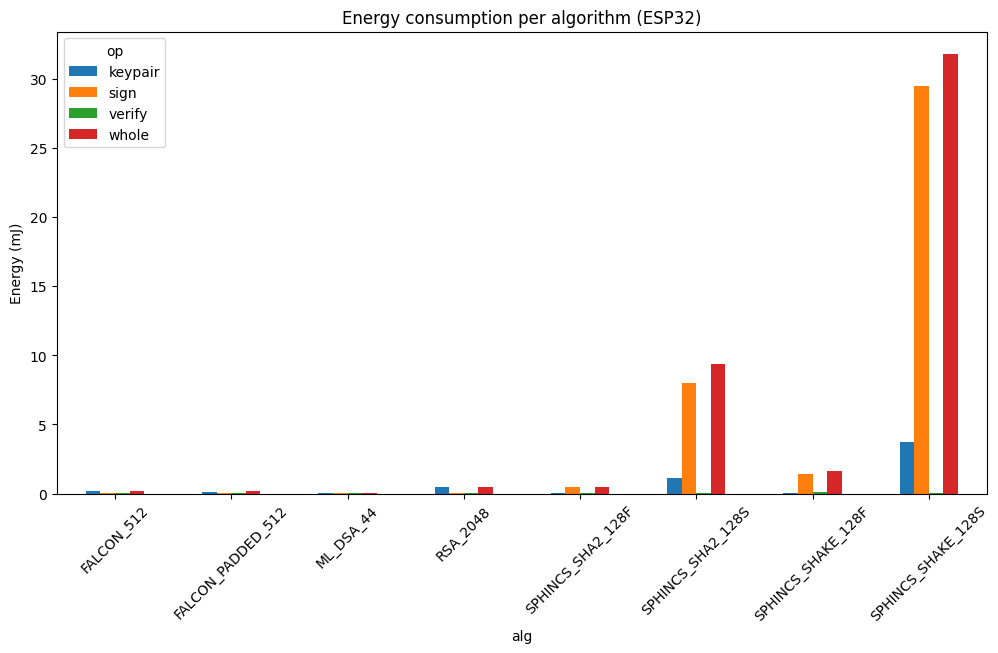

In [70]:
pivot_energy = energy_summary.pivot(
    index="alg",
    columns="op",
    values="energy_mean"
)

pivot_energy.plot(
    kind="bar",
    figsize=(12,6)
)

plt.ylabel("Energy (mJ)")
plt.title("Energy consumption per algorithm (ESP32)")
plt.xticks(rotation=45)

plt.show()